In [1]:
import numpy as np
import math

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [3]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        self.outputs = [input]
        current = input
        for module in self.modules:
            current = module.forward(current)
            self.outputs.append(current)
        self.output = current
        return self.output

    def backward(self, input, gradOutput):
        grad = gradOutput
        for i in range(len(self.modules) - 1, -1, -1):
            grad = self.modules[i].backward(self.outputs[i], grad)
        self.gradInput = grad
        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        params = []
        for module in self.modules:
            module_params = module.getParameters()
            if len(module_params) > 0:
                params.append(module_params)
        return params

    def getGradParameters(self):
        grad_params = []
        for module in self.modules:
            module_grad_params = module.getGradParameters()
            if len(module_grad_params) > 0:
                grad_params.append(module_grad_params)
        return grad_params

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        self.training = False
        for module in self.modules:
            module.evaluate()

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [4]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradW += gradOutput.T @ input
        self.gradb += np.sum(gradOutput, axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [5]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        exp_values = np.exp(self.output)
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        scalar_product = np.sum(gradOutput * self.output, axis=1, keepdims=True)
        self.gradInput = self.output * (gradOutput - scalar_product)

        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [6]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        log_sum_exp = np.log(np.sum(np.exp(self.output), axis=1, keepdims=True))
        self.output = self.output - log_sum_exp

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        exp_output = np.exp(self.output)
        sum_grad = np.sum(gradOutput, axis=1, keepdims=True)
        self.gradInput = gradOutput - exp_output * sum_grad

        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [7]:
class BatchNormalization(Module):
    EPS = 1e-3

    def __init__(self, alpha=0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        if self.moving_mean is None:
            self.moving_mean = np.zeros((1, input.shape[1]))
            self.moving_variance = np.ones((1, input.shape[1]))

        if self.training:
            self.batch_mean = np.mean(input, axis=0, keepdims=True)

            # biased variance: как в forward у PyTorch
            self.batch_variance = np.var(input, axis=0, keepdims=True)

            # unbiased variance: как в running_var у PyTorch
            if input.shape[0] > 1:
                unbiased_variance = np.var(input, axis=0, ddof=1, keepdims=True)
            else:
                unbiased_variance = self.batch_variance

            self.centered_input = input - self.batch_mean
            self.std_inv = 1.0 / np.sqrt(self.batch_variance + self.EPS)
            self.output = self.centered_input * self.std_inv

            self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
            self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * unbiased_variance
        else:
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            N = input.shape[0]
            self.gradInput = (1.0 / N) * self.std_inv * (
                N * gradOutput
                - np.sum(gradOutput, axis=0, keepdims=True)
                - self.centered_input * (self.std_inv ** 2) * np.sum(gradOutput * self.centered_input, axis=0, keepdims=True)
            )
        else:
            self.gradInput = gradOutput / np.sqrt(self.moving_variance + self.EPS)

        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"

In [8]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta += np.sum(gradOutput, axis=0)
        self.gradGamma += np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_57938/3935361484.py:3: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [9]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        if self.training:
            self.mask = np.random.binomial(1, 1 - self.p, size=input.shape)
            self.output = input * self.mask / (1 - self.p)
        else:
            self.output = input
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        if self.training:
            self.gradInput = gradOutput * self.mask / (1 - self.p)
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [10]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.padding_mode = padding_mode
        self.use_bias = bias  # было self.bias (bool)

        # Инициализация весов
        stdv = 1. / np.sqrt(in_channels * kernel_size * kernel_size)
        self.weight = np.random.uniform(-stdv, stdv,
                                        size=(out_channels, in_channels, kernel_size, kernel_size))
        self.gradWeight = np.zeros_like(self.weight)

        if self.use_bias:
            self.bias = np.random.uniform(-stdv, stdv, size=out_channels)
            self.gradBias = np.zeros_like(self.bias)
        else:
            self.bias = None
            self.gradBias = None

    # преобразует входной тензор в матрицу для свёртки
    def _im2col(self, input, kernel_size, stride_h, stride_w, pad):
        batch_size, in_c, in_h, in_w = input.shape
        out_h = (in_h + 2*pad - kernel_size) // stride_h + 1
        out_w = (in_w + 2*pad - kernel_size) // stride_w + 1

        # паддинг
        if pad > 0:
            input_pad = np.pad(input, ((0,0),(0,0),(pad,pad),(pad,pad)), mode='constant')
        else:
            input_pad = input

        # строим матрицу, где каждая строка это одно окно, развёрнутое в вектор
        cols = np.zeros((batch_size, in_c, kernel_size, kernel_size, out_h, out_w))
        for y in range(kernel_size):
            y_max = y + stride_h * out_h
            for x in range(kernel_size):
                x_max = x + stride_w * out_w
                cols[:, :, y, x, :, :] = input_pad[:, :, y:y_max:stride_h, x:x_max:stride_w]

        cols = cols.transpose(0, 4, 5, 1, 2, 3).reshape(batch_size * out_h * out_w, -1)
        return cols, out_h, out_w

    # преобразование на обратном проходе (раскладываем градиенты из таблицы обратно в картинку)
    def _col2im(self, grad_col, input_shape, kernel_size, stride_h, stride_w, pad):
        batch_size, in_c, in_h, in_w = input_shape
        out_h = (in_h + 2*pad - kernel_size) // stride_h + 1
        out_w = (in_w + 2*pad - kernel_size) // stride_w + 1

        grad_col = grad_col.reshape(batch_size, out_h, out_w, in_c, kernel_size, kernel_size)
        grad_col = grad_col.transpose(0, 3, 4, 5, 1, 2)

        grad_input_pad = np.zeros((batch_size, in_c, in_h + 2*pad, in_w + 2*pad))

        for y in range(kernel_size):
            for x in range(kernel_size):
                y_slice = slice(y, y + stride_h * out_h, stride_h)
                x_slice = slice(x, x + stride_w * out_w, stride_w)
                grad_input_pad[:, :, y_slice, x_slice] += grad_col[:, :, y, x, :, :]

        if pad > 0:
            return grad_input_pad[:, :, pad:-pad, pad:-pad]
        else:
            return grad_input_pad

    def updateOutput(self, input):
        self.input = input
        batch_size, in_c, in_h, in_w = input.shape
        k = self.kernel_size
        s = self.stride

        if isinstance(s, tuple):
            s_h, s_w = s
        else:
            s_h = s_w = s

        # паддинг
        if isinstance(self.padding, int):
            pad = self.padding
        elif self.padding == 'valid':
            pad = 0
        elif self.padding == 'same':
            out_h = (in_h + s_h - 1) // s_h
            out_w = (in_w + s_w - 1) // s_w
            pad = max(0, ((out_h - 1) * s_h + k - in_h) // 2)
        else:
            raise ValueError("Unsupported padding mode")

        cols, out_h, out_w = self._im2col(input, k, s_h, s_w, pad)

        # Матричное умножение
        W_col = self.weight.reshape(self.out_channels, -1)
        output_flat = cols @ W_col.T

        if self.use_bias:
            output_flat += self.bias

        self.output = output_flat.reshape(batch_size, out_h, out_w, self.out_channels).transpose(0, 3, 1, 2)
        self.cols = cols
        self.pad = pad
        self.out_h = out_h
        self.out_w = out_w
        self.s_h = s_h
        self.s_w = s_w

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, out_c, out_h, out_w = gradOutput.shape
        k = self.kernel_size
        in_c = self.in_channels

        grad_flat = gradOutput.transpose(0, 2, 3, 1).reshape(-1, self.out_channels)
        W_col = self.weight.reshape(self.out_channels, -1)
        grad_input_flat = grad_flat @ W_col

        self.gradInput = self._col2im(grad_input_flat, input.shape, k, self.s_h, self.s_w, self.pad)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        grad_flat = gradOutput.transpose(0, 2, 3, 1).reshape(-1, self.out_channels)
        gradW_flat = self.cols.T @ grad_flat
        self.gradWeight += gradW_flat.T.reshape(self.weight.shape)

        if self.use_bias:
            self.gradBias += np.sum(grad_flat, axis=0)

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.use_bias:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.use_bias:
            return [self.weight, self.bias]
        else:
            return [self.weight]

    def getGradParameters(self):
        if self.use_bias:
            return [self.gradWeight, self.gradBias]
        else:
            return [self.gradWeight]

    def __repr__(self):
        return "Conv2d"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [11]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        # Your code goes here. ################################################
        b, c, h, w = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        oh = (h + 2*p - k)//s + 1
        ow = (w + 2*p - k)//s + 1
        inp = np.pad(input, ((0,0),(0,0),(p,p),(p,p)), mode='constant', constant_values=-np.inf)
        self.output = np.zeros((b, c, oh, ow))
        self.mask = np.zeros_like(inp, dtype=bool)
        for i in range(oh):
            for j in range(ow):
                win = inp[:, :, i*s:i*s+k, j*s:j*s+k]
                maxv = win.max(axis=(2,3), keepdims=True)
                self.output[:, :, i, j] = maxv[:, :, 0, 0]
                self.mask[:, :, i*s:i*s+k, j*s:j*s+k] = (win == maxv)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        b, c, h, w = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        grad_in = np.zeros((b, c, h+2*p, w+2*p))
        oh, ow = self.output.shape[2], self.output.shape[3]
        for i in range(oh):
            for j in range(ow):
                grad_in[:, :, i*s:i*s+k, j*s:j*s+k] += gradOutput[:, :, i, j][:, :, None, None] * self.mask[:, :, i*s:i*s+k, j*s:j*s+k]
        self.gradInput = grad_in[:, :, p:-p, p:-p] if p>0 else grad_in
        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"

class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        # Your code goes here. ################################################
        b, c, h, w = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        oh = (h + 2*p - k)//s + 1
        ow = (w + 2*p - k)//s + 1
        inp = np.pad(input, ((0,0),(0,0),(p,p),(p,p)), mode='constant')
        self.output = np.zeros((b, c, oh, ow))
        for i in range(oh):
            for j in range(ow):
                win = inp[:, :, i*s:i*s+k, j*s:j*s+k]
                self.output[:, :, i, j] = win.mean(axis=(2,3))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        b, c, h, w = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        grad_in = np.zeros((b, c, h+2*p, w+2*p))
        oh, ow = gradOutput.shape[2], gradOutput.shape[3]
        for i in range(oh):
            for j in range(ow):
                grad_in[:, :, i*s:i*s+k, j*s:j*s+k] += gradOutput[:, :, i, j][:, :, None, None] / (k*k)
        self.gradInput = grad_in[:, :, p:-p, p:-p] if p>0 else grad_in
        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [12]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()

    def updateOutput(self, input):
        self.input_shape = input.shape
        self.output = np.max(input, axis=(2, 3), keepdims=True)
        self.mask = (input == self.output)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = self.mask * gradOutput
        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"


class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()

    def updateOutput(self, input):
        self.input_shape = input.shape
        self.output = np.mean(input, axis=(2, 3), keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        b, c, h, w = input.shape
        self.gradInput = np.ones_like(input) * gradOutput / (h * w)
        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [13]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.input_shape = input.shape
        end_dim = self.end_dim if self.end_dim >= 0 else len(self.input_shape) + self.end_dim

        # вычисляем размерность
        flatten_dim = 1
        for i in range(self.start_dim, end_dim + 1):
            flatten_dim *= self.input_shape[i]

        # собираем новую форму
        new_shape = self.input_shape[:self.start_dim] + (flatten_dim,) + self.input_shape[end_dim + 1:]
        self.output = input.reshape(new_shape)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [14]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [15]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input > 0, input, input * self.slope)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = np.where(input > 0, gradOutput, gradOutput * self.slope)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [16]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        grad = np.where(input > 0, 1, self.alpha * np.exp(input))
        self.gradInput = gradOutput * grad
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [17]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.log(1 + np.exp(input))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput * (1 / (1 + np.exp(-input)))
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [18]:
class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        self.erf_term = np.vectorize(math.erf)(input / np.sqrt(2.0))
        self.output = 0.5 * input * (1.0 + self.erf_term)
        return self.output

    def updateGradInput(self, input, gradOutput):
        grad = 0.5 * (1.0 + self.erf_term) + input * np.exp(-0.5 * input**2) / np.sqrt(2.0 * math.pi)
        self.gradInput = gradOutput * grad
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [19]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [20]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [21]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        batch_size = input.shape[0]
        self.output = -np.sum(target * np.log(input_clamp)) / batch_size
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        batch_size = input.shape[0]
        self.gradInput = -target / input_clamp / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [22]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        batch_size = input.shape[0]
        self.output = -np.sum(target * input) / batch_size
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        batch_size = input.shape[0]
        self.gradInput = -target / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \ 2-я часть задания: реализация моделей на своих классах. Что должно быть:

Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \
Дополнительно в оценке каждой модели будет учитываться:

Наличие правильно выбранной метрики и лосс функции.
Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
Наличие шедулера для lr.
Наличие вормапа.
Наличие механизма ранней остановки и сохранение лучшей модели.
Свитч лося (метрики) и оптимайзера.

# Вторая часть  

1.Реализация ADAM

Реализовала Adam под свою систему модулей на numpy. Основная особенность в том, что Sequential возвращает параметры и градиенты в виде вложенных списков (по слоям), поэтому я добавила рекурсивную функцию _collect_params_and_grads, которая разворачивает их в один плоский список — это нужно, чтобы оптимизатор мог единообразно пройтись по всем весам. Дальше уже используется стандартная логика Adam: считаются моменты m и v, делается корекция смещения и обновление параметров. Градиенты обнуляются через model.zeroGradParameters().Еще добавила weight_decay и возможность менять шаг обучения через set_lr для scheduler.

In [23]:

class Adam:
    def __init__(self, model, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0

        self.params, self.grads = self._collect_params_and_grads(
            self.model.getParameters(),
            self.model.getGradParameters()
        )

        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]

    def _collect_params_and_grads(self, params, grads):
        flat_params = []
        flat_grads = []

        def walk(p_obj, g_obj):
            if isinstance(p_obj, list):
                for p_item, g_item in zip(p_obj, g_obj):
                    walk(p_item, g_item)
            else:
                flat_params.append(p_obj)
                flat_grads.append(g_obj)

        walk(params, grads)
        return flat_params, flat_grads

    def zero_grad(self):
        self.model.zeroGradParameters()

    def step(self):
        self.t += 1

        for i, (p, g) in enumerate(zip(self.params, self.grads)):
            grad = g

            if self.weight_decay != 0.0:
                grad = grad + self.weight_decay * p

            self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (grad ** 2)

            m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def set_lr(self, lr):
        self.lr = lr

In [24]:
np.random.seed(0)

model = Sequential()
model.add(Linear(3, 4))
model.add(ReLU())
model.add(Linear(4, 1))

criterion = MSECriterion()
optimizer = Adam(model, lr=1e-2)

X = np.random.randn(16, 3)
y = np.random.randn(16, 1)

for step in range(20):
    optimizer.zero_grad()

    out = model.forward(X)
    loss = criterion.forward(out, y)

    grad_loss = criterion.backward(out, y)
    model.backward(X, grad_loss)

    optimizer.step()

    print(step, loss)

0 1.2069875591438173
1 1.1586386634420842
2 1.113708018984844
3 1.0724042393980784
4 1.03490309790689
5 1.002408920250734
6 0.9725687022676095
7 0.9451974839218571
8 0.9200907187145001
9 0.8970251308366591
10 0.8762921520250213
11 0.8571027993789762
12 0.8392705610700145
13 0.8227041249664035
14 0.8075354740398838
15 0.7936022189171097
16 0.7818907936248032
17 0.7723178861842032
18 0.7636518033167227
19 0.7558139259679428


Scheduler для моего оптимизатора

In [25]:
class ReduceLROnPlateau:
    def __init__(self, optimizer, factor=0.5, patience=2, min_lr=1e-6):
        self.optimizer = optimizer
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr

        self.best = np.inf
        self.bad_epochs = 0

    def step(self, current_val_loss):
        if current_val_loss < self.best:
            self.best = current_val_loss
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1

        if self.bad_epochs >= self.patience:
            new_lr = max(self.optimizer.lr * self.factor, self.min_lr)
            self.optimizer.set_lr(new_lr)
            self.bad_epochs = 0

# 3. Модель для задачи мультиклассификации на MNIST

Загрузка и подготовка датасета

In [43]:
import copy
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [27]:
def one_hot_encode(y, num_classes=10):
    y = np.asarray(y).astype(int)
    y_one_hot = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    y_one_hot[np.arange(y.shape[0]), y] = 1.0
    return y_one_hot


def load_mnist_data(val_size=0.1, random_state=42):
    # train_full: 60000, test: 10000
    (X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

    # float32 + нормализация в [0, 1]
    X_train_full = X_train_full.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0

    # добавляем канал: (N, 1, 28, 28)
    X_train_full = X_train_full[:, None, :, :]
    X_test = X_test[:, None, :, :]

    # train / val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size,
        random_state=random_state,
        stratify=y_train_full
    )

    # one-hot target под ClassNLLCriterion
    y_train_oh = one_hot_encode(y_train, 10)
    y_val_oh = one_hot_encode(y_val, 10)
    y_test_oh = one_hot_encode(y_test, 10)

    return {
        "X_train": X_train,
        "y_train": y_train_oh,
        "y_train_labels": y_train,

        "X_val": X_val,
        "y_val": y_val_oh,
        "y_val_labels": y_val,

        "X_test": X_test,
        "y_test": y_test_oh,
        "y_test_labels": y_test,
    }



In [28]:
data = load_mnist_data(val_size=0.1, random_state=42)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(54000, 1, 28, 28) (54000, 10)
(6000, 1, 28, 28) (6000, 10)
(10000, 1, 28, 28) (10000, 10)


Делим на батчи

In [29]:

def iterate_minibatches(X, y, batch_size, shuffle=True):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_idx = indices[start_idx:end_idx]
        yield X[batch_idx], y[batch_idx]




Сохранение / восстановление параметров модели

In [30]:
def _flatten_nested_list(nested):
    flat = []

    def walk(obj):
        if isinstance(obj, list):
            for item in obj:
                walk(item)
        else:
            flat.append(obj)

    walk(nested)
    return flat


def get_model_parameters_copy(model):
    params = _flatten_nested_list(model.getParameters())
    return [p.copy() for p in params]


def set_model_parameters(model, saved_params):
    current_params = _flatten_nested_list(model.getParameters())
    for p, saved_p in zip(current_params, saved_params):
        p[...] = saved_p


Метрика accuracy

In [31]:
def accuracy_from_logits(log_probs, y_one_hot):
    pred = np.argmax(log_probs, axis=1)
    true = np.argmax(y_one_hot, axis=1)
    return np.mean(pred == true)


Функции обучения и оценки (функция для одной эпохи обучения,
функция для валидации,
функция полного цикла обучения)

In [32]:
def train_one_epoch(model, criterion, optimizer, X_train, y_train, batch_size=128):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    for x_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True):
        batch_size_actual = x_batch.shape[0]

        optimizer.zero_grad()

        # forward
        output = model.forward(x_batch)
        loss = criterion.forward(output, y_batch)

        # backward
        grad_loss = criterion.backward(output, y_batch)
        model.backward(x_batch, grad_loss)

        # step
        optimizer.step()

        # статистика
        acc = accuracy_from_logits(output, y_batch)

        total_loss += loss * batch_size_actual
        total_acc += acc * batch_size_actual
        total_samples += batch_size_actual

    epoch_loss = total_loss / total_samples
    epoch_acc = total_acc / total_samples

    return epoch_loss, epoch_acc




In [33]:

def evaluate(model, criterion, X, y, batch_size=128):
    model.evaluate()

    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    for x_batch, y_batch in iterate_minibatches(X, y, batch_size=batch_size, shuffle=False):
        batch_size_actual = x_batch.shape[0]

        output = model.forward(x_batch)
        loss = criterion.forward(output, y_batch)
        acc = accuracy_from_logits(output, y_batch)

        total_loss += loss * batch_size_actual
        total_acc += acc * batch_size_actual
        total_samples += batch_size_actual

    epoch_loss = total_loss / total_samples
    epoch_acc = total_acc / total_samples

    return epoch_loss, epoch_acc


In [34]:

def fit(
    model,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=10,
    batch_size=128,
    scheduler=None,
    warmup_epochs=0,
    early_stopping_patience=None,
    verbose=True
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    best_val_loss = np.inf
    best_params = None
    patience_counter = 0
    base_lr = optimizer.lr

    for epoch in range(epochs):
        # warmup по эпохам
        if warmup_epochs > 0 and epoch < warmup_epochs:
            new_lr = base_lr * (epoch + 1) / warmup_epochs
            optimizer.set_lr(new_lr)

        train_loss, train_acc = train_one_epoch(
            model, criterion, optimizer,
            X_train, y_train,
            batch_size=batch_size
        )

        val_loss, val_acc = evaluate(
            model, criterion,
            X_val, y_val,
            batch_size=batch_size
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.lr)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"lr={optimizer.lr:.6f} | "
                f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
            )

        # сохраняем лучшую модель
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = get_model_parameters_copy(model)
            patience_counter = 0
        else:
            patience_counter += 1

        # scheduler после эпохи
        if scheduler is not None:
            scheduler.step(val_loss)

        # early stopping
        if early_stopping_patience is not None and patience_counter >= early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch + 1}")
            break

    # возвращаем лучшую модель
    if best_params is not None:
        set_model_parameters(model, best_params)

    return history


Определим архитектуру

In [35]:
def build_mnist_cnn():
    model = Sequential()

    model.add(Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1, bias=True))
    model.add(ReLU())

    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1, bias=True))
    model.add(ReLU())

    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))

    model.add(Linear(16 * 7 * 7, 64))
    model.add(ReLU())

    model.add(Linear(64, 10))

    # лог-вероятности
    model.add(LogSoftMax())

    return model

In [36]:
model = build_mnist_cnn()

Функция для проверки размерности

In [37]:
def check_model_shapes(model, X_sample):
    print("Input shape:", X_sample.shape)

    current = X_sample
    for i, layer in enumerate(model.modules):
        current = layer.forward(current)
        print(f"Layer {i+1:02d} | {layer} | output shape = {current.shape}")

    return current

In [38]:
out_sample = check_model_shapes(model, X_train[:8])
print("Final output shape:", out_sample.shape)

Input shape: (8, 1, 28, 28)
Layer 01 | Conv2d | output shape = (8, 8, 28, 28)
Layer 02 | ReLU | output shape = (8, 8, 28, 28)
Layer 03 | MaxPool2d | output shape = (8, 8, 14, 14)
Layer 04 | Conv2d | output shape = (8, 16, 14, 14)
Layer 05 | ReLU | output shape = (8, 16, 14, 14)
Layer 06 | MaxPool2d | output shape = (8, 16, 7, 7)
Layer 07 | Flatten | output shape = (8, 784)
Layer 08 | Linear 784 -> 64 | output shape = (8, 64)
Layer 09 | ReLU | output shape = (8, 64)
Layer 10 | Linear 64 -> 10 | output shape = (8, 10)
Layer 11 | LogSoftMax | output shape = (8, 10)
Final output shape: (8, 10)


Запускаем модель

In [39]:
criterion = ClassNLLCriterion()
optimizer = Adam(model, lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=2, min_lr=1e-5)


In [40]:
history = fit(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=10,
    batch_size=128,
    scheduler=scheduler,
    warmup_epochs=2,
    early_stopping_patience=4,
    verbose=True)

Epoch 1/10 | lr=0.000500 | train_loss=0.6391 | train_acc=0.8201 | val_loss=0.2255 | val_acc=0.9330
Epoch 2/10 | lr=0.001000 | train_loss=0.1486 | train_acc=0.9553 | val_loss=0.1171 | val_acc=0.9660
Epoch 3/10 | lr=0.001000 | train_loss=0.0944 | train_acc=0.9711 | val_loss=0.0984 | val_acc=0.9693
Epoch 4/10 | lr=0.001000 | train_loss=0.0738 | train_acc=0.9772 | val_loss=0.0768 | val_acc=0.9763
Epoch 5/10 | lr=0.001000 | train_loss=0.0644 | train_acc=0.9793 | val_loss=0.0735 | val_acc=0.9757
Epoch 6/10 | lr=0.001000 | train_loss=0.0550 | train_acc=0.9829 | val_loss=0.0716 | val_acc=0.9797
Epoch 7/10 | lr=0.001000 | train_loss=0.0484 | train_acc=0.9847 | val_loss=0.0785 | val_acc=0.9757
Epoch 8/10 | lr=0.001000 | train_loss=0.0437 | train_acc=0.9862 | val_loss=0.0671 | val_acc=0.9805
Epoch 9/10 | lr=0.001000 | train_loss=0.0384 | train_acc=0.9876 | val_loss=0.0651 | val_acc=0.9813
Epoch 10/10 | lr=0.001000 | train_loss=0.0348 | train_acc=0.9887 | val_loss=0.0692 | val_acc=0.9830


Построение графиков


In [41]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()



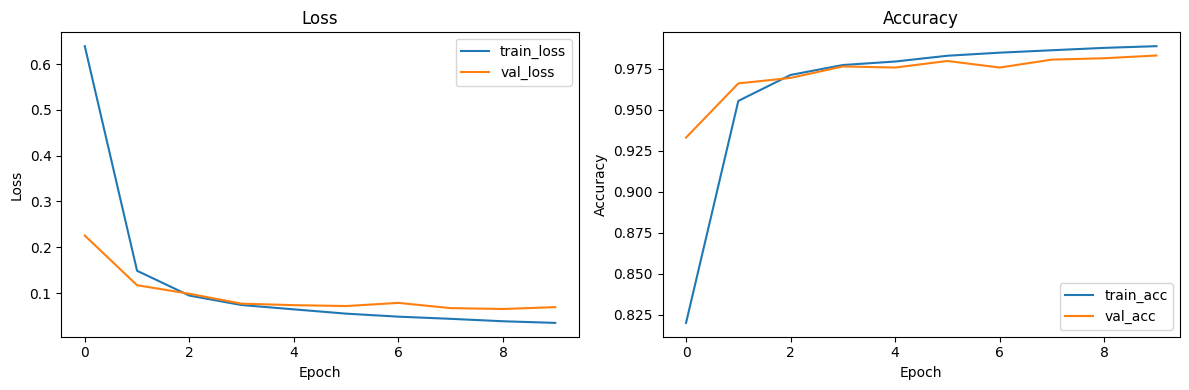

In [44]:
plot_history(history)

Тест

In [45]:
test_loss, test_acc = evaluate(model, criterion, X_test, y_test, batch_size=128)
print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

Test loss: 0.0497
Test acc:  0.9831


# 4.Автоэнкодер для MNIST.

Для автоэнкодера использовался тот же MNIST, что и в задаче классификации. В отличие от классификации, целевой переменной здесь является само входное изображение, поэтому модель обучается восстанавливать вход

In [50]:
X_train_ae = X_train
X_val_ae = X_val
X_test_ae = X_test

Добавлен служебный слой Reshape, который нужен в декодере для преобразования вектора длины 784 обратно в изображение формата 1x28x28.

In [51]:
class Reshape(Module):
    def __init__(self, *shape):
        super(Reshape, self).__init__()
        self.target_shape = shape

    def updateOutput(self, input):
        self.input_shape = input.shape
        self.output = input.reshape((input.shape[0],) + self.target_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return f"Reshape{self.target_shape}"

Определим архитектуру.  
encoder состоит из свёрточных и полносвязных слоёв, decoder — из полносвязных слоёв с восстановлением изображения. В архитектуре использованы batch normalization, channelwise scaling и dropout.

In [52]:
def build_mnist_autoencoder(latent_dim=32, dropout_p=0.2, bn_alpha=0.9):
    model = Sequential()

    # ========= Encoder =========
    # (N, 1, 28, 28) -> (N, 8, 28, 28)
    model.add(Conv2d(1, 8, kernel_size=3, stride=1, padding=1, bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))   # -> (N, 8, 14, 14)

    # (N, 8, 14, 14) -> (N, 16, 14, 14)
    model.add(Conv2d(8, 16, kernel_size=3, stride=1, padding=1, bias=True))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))   # -> (N, 16, 7, 7)

    model.add(Flatten(start_dim=1))                            # -> (N, 16*7*7 = 784)

    model.add(Linear(16 * 7 * 7, 128))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(dropout_p))

    model.add(Linear(128, latent_dim))                         # latent vector

    # ========= Decoder =========
    model.add(Linear(latent_dim, 128))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(dropout_p))

    model.add(Linear(128, 28 * 28))
    model.add(Reshape(1, 28, 28))

    return model

Добавлена отдельная проверка размерностей по слоям, чтобы до обучения убедиться, что encoder и decoder согласованы, а выход автоэнкодера имеет ту же форму, что и вход.

In [53]:
def check_autoencoder_shapes(model, X_sample):
    print("Input shape:", X_sample.shape)

    current = X_sample
    for i, layer in enumerate(model.modules):
        current = layer.forward(current)
        print(f"Layer {i+1:02d} | {layer} | output shape = {current.shape}")

    return current

In [54]:
model_ae = build_mnist_autoencoder()
out_sample_ae = check_autoencoder_shapes(model_ae, X_train_ae[:8])
print("Final output shape:", out_sample_ae.shape)

Input shape: (8, 1, 28, 28)
Layer 01 | Conv2d | output shape = (8, 8, 28, 28)
Layer 02 | ReLU | output shape = (8, 8, 28, 28)
Layer 03 | MaxPool2d | output shape = (8, 8, 14, 14)
Layer 04 | Conv2d | output shape = (8, 16, 14, 14)
Layer 05 | ReLU | output shape = (8, 16, 14, 14)
Layer 06 | MaxPool2d | output shape = (8, 16, 7, 7)
Layer 07 | Flatten | output shape = (8, 784)
Layer 08 | Linear 784 -> 128 | output shape = (8, 128)
Layer 09 | BatchNormalization | output shape = (8, 128)
Layer 10 | ChannelwiseScaling | output shape = (8, 128)
Layer 11 | ReLU | output shape = (8, 128)
Layer 12 | Dropout | output shape = (8, 128)
Layer 13 | Linear 128 -> 32 | output shape = (8, 32)
Layer 14 | Linear 32 -> 128 | output shape = (8, 128)
Layer 15 | BatchNormalization | output shape = (8, 128)
Layer 16 | ChannelwiseScaling | output shape = (8, 128)
Layer 17 | ReLU | output shape = (8, 128)
Layer 18 | Dropout | output shape = (8, 128)
Layer 19 | Linear 128 -> 784 | output shape = (8, 784)
Layer 20 

Добавлена отдельная проверка размерностей по слоям, чтобы до обучения убедиться, что encoder и decoder согласованы, а выход автоэнкодера имеет ту же форму, что и вход.

In [55]:
def iterate_minibatches_autoencoder(X, batch_size, shuffle=True):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_idx = indices[start_idx:end_idx]
        yield X[batch_idx]

В качестве дополнительной метрики использовался RMSE, так как он интерпретируется проще, чем MSE, и хорошо отражает качество реконструкции.



In [56]:
def rmse(pred, target):
    return np.sqrt(np.mean((pred - target) ** 2))

Функции обучения и оценки (функция для одной эпохи обучения, функция для валидации, функция полного цикла обучения)

In [57]:
def train_one_epoch_autoencoder(model, criterion, optimizer, X_train, batch_size=128):
    model.train()

    total_loss = 0.0
    total_rmse = 0.0
    total_samples = 0

    for x_batch in iterate_minibatches_autoencoder(X_train, batch_size=batch_size, shuffle=True):
        batch_size_actual = x_batch.shape[0]

        optimizer.zero_grad()

        output = model.forward(x_batch)
        loss = criterion.forward(output, x_batch)

        grad_loss = criterion.backward(output, x_batch)
        model.backward(x_batch, grad_loss)

        optimizer.step()

        batch_rmse = rmse(output, x_batch)

        total_loss += loss * batch_size_actual
        total_rmse += batch_rmse * batch_size_actual
        total_samples += batch_size_actual

    epoch_loss = total_loss / total_samples
    epoch_rmse = total_rmse / total_samples

    return epoch_loss, epoch_rmse

In [58]:
def evaluate_autoencoder(model, criterion, X, batch_size=128):
    model.evaluate()

    total_loss = 0.0
    total_rmse = 0.0
    total_samples = 0

    for x_batch in iterate_minibatches_autoencoder(X, batch_size=batch_size, shuffle=False):
        batch_size_actual = x_batch.shape[0]

        output = model.forward(x_batch)
        loss = criterion.forward(output, x_batch)
        batch_rmse = rmse(output, x_batch)

        total_loss += loss * batch_size_actual
        total_rmse += batch_rmse * batch_size_actual
        total_samples += batch_size_actual

    epoch_loss = total_loss / total_samples
    epoch_rmse = total_rmse / total_samples

    return epoch_loss, epoch_rmse

In [59]:
def fit_autoencoder(
    model,
    criterion,
    optimizer,
    X_train,
    X_val,
    epochs=10,
    batch_size=128,
    scheduler=None,
    warmup_epochs=0,
    early_stopping_patience=None,
    verbose=True
):
    history = {
        "train_loss": [],
        "train_rmse": [],
        "val_loss": [],
        "val_rmse": [],
        "lr": []
    }

    best_val_loss = np.inf
    best_params = None
    patience_counter = 0
    base_lr = optimizer.lr

    for epoch in range(epochs):
        if warmup_epochs > 0 and epoch < warmup_epochs:
            new_lr = base_lr * (epoch + 1) / warmup_epochs
            optimizer.set_lr(new_lr)

        train_loss, train_rmse = train_one_epoch_autoencoder(
            model, criterion, optimizer,
            X_train,
            batch_size=batch_size
        )

        val_loss, val_rmse = evaluate_autoencoder(
            model, criterion,
            X_val,
            batch_size=batch_size
        )

        history["train_loss"].append(train_loss)
        history["train_rmse"].append(train_rmse)
        history["val_loss"].append(val_loss)
        history["val_rmse"].append(val_rmse)
        history["lr"].append(optimizer.lr)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"lr={optimizer.lr:.6f} | "
                f"train_loss={train_loss:.4f} | train_rmse={train_rmse:.4f} | "
                f"val_loss={val_loss:.4f} | val_rmse={val_rmse:.4f}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = get_model_parameters_copy(model)
            patience_counter = 0
        else:
            patience_counter += 1

        if scheduler is not None:
            scheduler.step(val_loss)

        if early_stopping_patience is not None and patience_counter >= early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_params is not None:
        set_model_parameters(model, best_params)

    return history

In [62]:
model_ae = build_mnist_autoencoder(latent_dim=32, dropout_p=0.2, bn_alpha=0.9)

criterion_ae = MSECriterion()
optimizer_ae = Adam(model_ae, lr=1e-3)
scheduler_ae = ReduceLROnPlateau(optimizer_ae, factor=0.5, patience=2, min_lr=1e-5)


In [63]:
history_ae = fit_autoencoder(
    model=model_ae,
    criterion=criterion_ae,
    optimizer=optimizer_ae,
    X_train=X_train_ae,
    X_val=X_val_ae,
    epochs=10,
    batch_size=64,
    scheduler=scheduler_ae,
    warmup_epochs=1,
    early_stopping_patience=4,
    verbose=True
)



Epoch 1/10 | lr=0.001000 | train_loss=30.6769 | train_rmse=0.1955 | val_loss=20.4749 | val_rmse=0.1616
Epoch 2/10 | lr=0.001000 | train_loss=22.9107 | train_rmse=0.1709 | val_loss=17.9517 | val_rmse=0.1513
Epoch 3/10 | lr=0.001000 | train_loss=21.7189 | train_rmse=0.1664 | val_loss=17.1940 | val_rmse=0.1481
Epoch 4/10 | lr=0.001000 | train_loss=21.1995 | train_rmse=0.1644 | val_loss=16.0864 | val_rmse=0.1432
Epoch 5/10 | lr=0.001000 | train_loss=20.8131 | train_rmse=0.1629 | val_loss=17.0846 | val_rmse=0.1476
Epoch 6/10 | lr=0.001000 | train_loss=20.5025 | train_rmse=0.1617 | val_loss=17.3486 | val_rmse=0.1487
Epoch 7/10 | lr=0.000500 | train_loss=20.1271 | train_rmse=0.1602 | val_loss=15.4039 | val_rmse=0.1401
Epoch 8/10 | lr=0.000500 | train_loss=19.9478 | train_rmse=0.1595 | val_loss=14.9236 | val_rmse=0.1379
Epoch 9/10 | lr=0.000500 | train_loss=19.8277 | train_rmse=0.1590 | val_loss=14.6204 | val_rmse=0.1365
Epoch 10/10 | lr=0.000500 | train_loss=19.6947 | train_rmse=0.1585 | val_

Строим графики

In [60]:
def plot_autoencoder_history(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="train_loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Autoencoder Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_rmse"], marker='o', label="train_rmse")
    plt.plot(epochs, history["val_rmse"], marker='o', label="val_rmse")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("Autoencoder RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["lr"], marker='o', label="lr")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("Learning Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

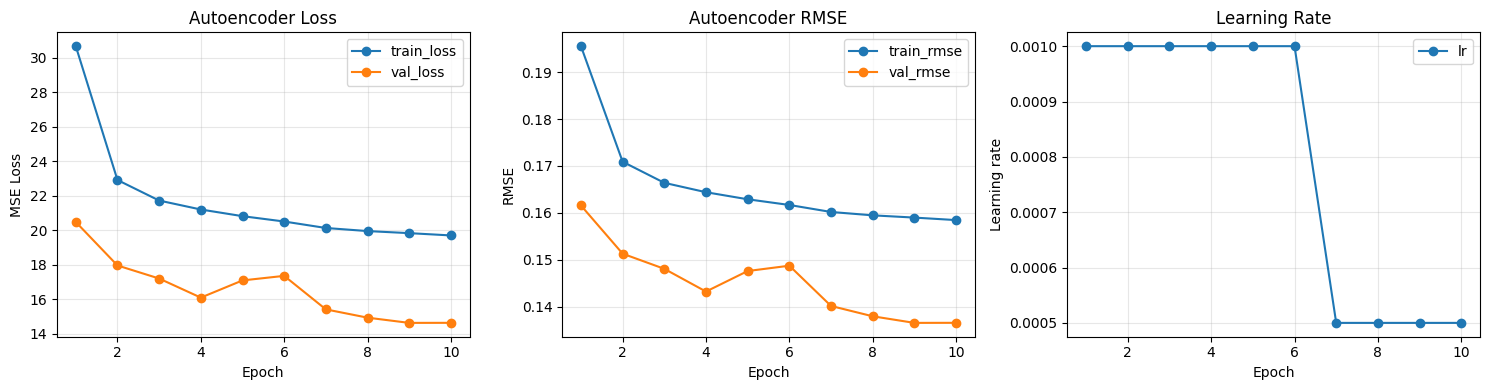

In [64]:
plot_autoencoder_history(history_ae)

Для оценки качества автоэнкодера дополнительно визуализируются пары «оригинал — реконструкция», что позволяет наглядно оценить качество восстановления изображений.

In [67]:
def show_reconstructions(model, X, n=8):
    model.evaluate()

    idx = np.random.choice(len(X), size=n, replace=False)
    X_sample = X[idx]
    recon = model.forward(X_sample)

    plt.figure(figsize=(2 * n, 4))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(X_sample[i, 0], cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(recon[i, 0], cmap="gray")
        plt.title("Recon")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Тест

Autoencoder test loss: 37.5251
Autoencoder test RMSE: 0.2186


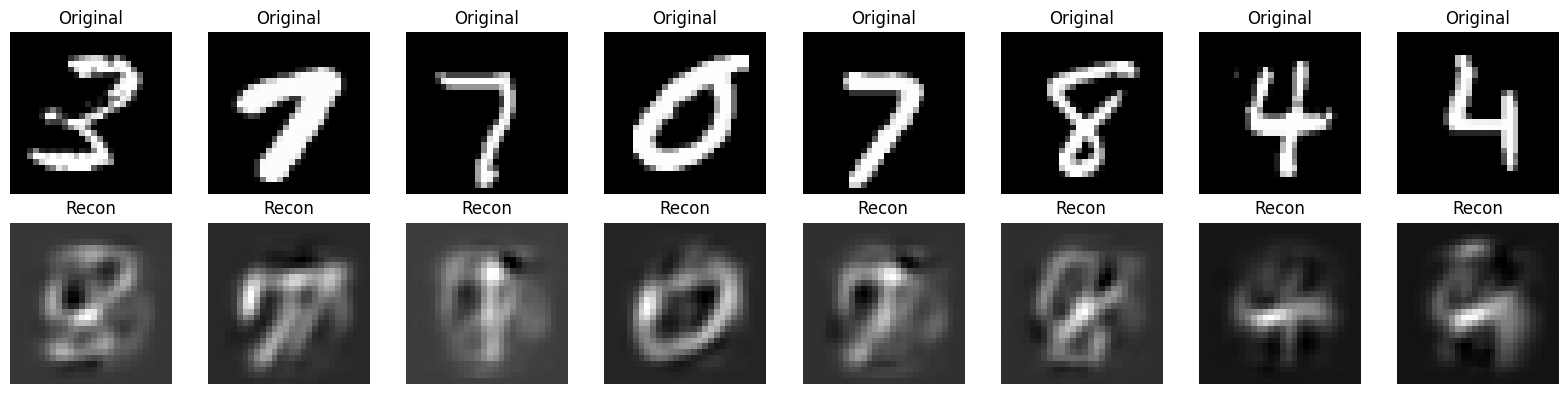

In [65]:
test_loss_ae, test_rmse_ae = evaluate_autoencoder(
    model_ae, criterion_ae, X_test_ae, batch_size=64
)

print(f"Autoencoder test loss: {test_loss_ae:.4f}")
print(f"Autoencoder test RMSE: {test_rmse_ae:.4f}")

show_reconstructions(model_ae, X_test_ae_small, n=8)

# 2.Модель для задачи мультирегрессии на синтетических данных

Сгенерированы синтетические данные для задачи мультирегрессии с нелинейными зависимостями и добавленным шумом.Каждый таргет зависит от разных признаков:

y1-
линейная часть
квадрат
синус,
y2-
линейная комбинация
произведение признаков
косинус,
y3-
линейная часть
куб

In [69]:
def make_synthetic_multiregression(
    n_samples=5000,
    n_features=12,
    n_targets=3,
    noise_std=0.1,
    random_state=42
):
    np.random.seed(random_state)

    X = np.random.randn(n_samples, n_features).astype(np.float32)

    y1 = (
        2.0 * X[:, 0]
        - 1.5 * X[:, 1]
        + 0.7 * X[:, 2] ** 2
        + np.sin(X[:, 3])
    )

    y2 = (
        -1.0 * X[:, 4]
        + 2.5 * X[:, 5]
        - 0.8 * X[:, 6] * X[:, 7]
        + np.cos(X[:, 8])
    )

    y3 = (
        1.2 * X[:, 9]
        - 1.8 * X[:, 10]
        + 0.5 * X[:, 11] ** 3
    )

    y = np.stack([y1, y2, y3], axis=1).astype(np.float32)

    noise = noise_std * np.random.randn(*y.shape).astype(np.float32)
    y = y + noise

    return X, y

In [70]:
X, y = make_synthetic_multiregression(
    n_samples=5000,
    n_features=12,
    n_targets=3,
    noise_std=0.1,
    random_state=42
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

Признаки стандартизировала по обучающей выборке для стабилизации обучения модели.

In [71]:
def standardize_train_val_test(X_train, X_val, X_test):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True) + 1e-8

    X_train_std = (X_train - mean) / std
    X_val_std = (X_val - mean) / std
    X_test_std = (X_test - mean) / std

    return X_train_std, X_val_std, X_test_std

In [72]:
X_train, X_val, X_test = standardize_train_val_test(X_train, X_val, X_test)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (3200, 12) (3200, 3)
Val:   (800, 12) (800, 3)
Test:  (1000, 12) (1000, 3)


Построение моделей: small / medium / large

In [73]:
def build_regression_model(model_size, n_in, n_out, activation="relu", dropout_p=0.2, bn_alpha=0.9):
    model = Sequential()

    if activation == "relu":
        act = lambda: ReLU()
    elif activation == "leaky_relu":
        act = lambda: LeakyReLU(0.1)
    elif activation == "elu":
        act = lambda: ELU(alpha=1.0)
    else:
        raise ValueError("Unsupported activation")

    if model_size == "small":
        hidden_dims = [64]
    elif model_size == "medium":
        hidden_dims = [128, 64]
    elif model_size == "large":
        hidden_dims = [256, 128, 64]
    else:
        raise ValueError("model_size must be 'small', 'medium' or 'large'")

    prev_dim = n_in

    for h in hidden_dims:
        model.add(Linear(prev_dim, h))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(ChannelwiseScaling(h))
        model.add(act())
        model.add(Dropout(dropout_p))
        prev_dim = h

    model.add(Linear(prev_dim, n_out))
    return model

Метрики МАЕ и R^2

In [82]:
def mae(pred, target):
    return np.mean(np.abs(pred - target))

def r2_score_numpy(pred, target):
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - np.mean(target, axis=0, keepdims=True)) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-8)



Разбиваем на батчи

In [76]:
def iterate_minibatches_regression(X, y, batch_size, shuffle=True):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_idx = indices[start_idx:end_idx]
        yield X[batch_idx], y[batch_idx]

Функции обучения и оценки (функция для одной эпохи обучения, функция для валидации, функция полного цикла обучения)

In [77]:
def train_one_epoch_regression(model, criterion, optimizer, X_train, y_train, batch_size=128):
    model.train()

    total_loss = 0.0
    total_mae = 0.0
    total_samples = 0

    for x_batch, y_batch in iterate_minibatches_regression(X_train, y_train, batch_size=batch_size, shuffle=True):
        batch_size_actual = x_batch.shape[0]

        optimizer.zero_grad()

        output = model.forward(x_batch)
        loss = criterion.forward(output, y_batch)

        grad_loss = criterion.backward(output, y_batch)
        model.backward(x_batch, grad_loss)

        optimizer.step()

        batch_mae = mae(output, y_batch)

        total_loss += loss * batch_size_actual
        total_mae += batch_mae * batch_size_actual
        total_samples += batch_size_actual

    epoch_loss = total_loss / total_samples
    epoch_mae = total_mae / total_samples

    return epoch_loss, epoch_mae

In [78]:
def evaluate_regression(model, criterion, X, y, batch_size=128):
    model.evaluate()

    total_loss = 0.0
    total_mae = 0.0
    total_samples = 0

    all_preds = []
    all_targets = []

    for x_batch, y_batch in iterate_minibatches_regression(X, y, batch_size=batch_size, shuffle=False):
        batch_size_actual = x_batch.shape[0]

        output = model.forward(x_batch)
        loss = criterion.forward(output, y_batch)
        batch_mae = mae(output, y_batch)

        total_loss += loss * batch_size_actual
        total_mae += batch_mae * batch_size_actual
        total_samples += batch_size_actual

        all_preds.append(output)
        all_targets.append(y_batch)

    epoch_loss = total_loss / total_samples
    epoch_mae = total_mae / total_samples

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    epoch_r2 = r2_score_numpy(all_preds, all_targets)

    return epoch_loss, epoch_mae, epoch_r2

In [79]:
def fit_regression(
    model,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    batch_size=128,
    scheduler=None,
    warmup_epochs=0,
    early_stopping_patience=None,
    verbose=True
):
    history = {
        "train_loss": [],
        "train_mae": [],
        "val_loss": [],
        "val_mae": [],
        "val_r2": [],
        "lr": []
    }

    best_val_loss = np.inf
    best_params = None
    patience_counter = 0
    base_lr = optimizer.lr

    for epoch in range(epochs):
        if warmup_epochs > 0 and epoch < warmup_epochs:
            new_lr = base_lr * (epoch + 1) / warmup_epochs
            optimizer.set_lr(new_lr)

        train_loss, train_mae = train_one_epoch_regression(
            model, criterion, optimizer,
            X_train, y_train,
            batch_size=batch_size
        )

        val_loss, val_mae, val_r2 = evaluate_regression(
            model, criterion,
            X_val, y_val,
            batch_size=batch_size
        )

        history["train_loss"].append(train_loss)
        history["train_mae"].append(train_mae)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["val_r2"].append(val_r2)
        history["lr"].append(optimizer.lr)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"lr={optimizer.lr:.6f} | "
                f"train_loss={train_loss:.4f} | train_mae={train_mae:.4f} | "
                f"val_loss={val_loss:.4f} | val_mae={val_mae:.4f} | val_r2={val_r2:.4f}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = get_model_parameters_copy(model)
            patience_counter = 0
        else:
            patience_counter += 1

        if scheduler is not None:
            scheduler.step(val_loss)

        if early_stopping_patience is not None and patience_counter >= early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_params is not None:
        set_model_parameters(model, best_params)

    return history

Строим графики

In [80]:
def plot_regression_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="train_loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_mae"], marker='o', label="train_mae")
    plt.plot(epochs, history["val_mae"], marker='o', label="val_mae")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"{title_prefix} MAE")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["lr"], marker='o', label="lr")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title(f"{title_prefix} Learning Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Запускаем модели и строим графики

Training model: small
Epoch 1/20 | lr=0.000500 | train_loss=25.4903 | train_mae=2.2340 | val_loss=24.8604 | val_mae=2.2186 | val_r2=-0.0334
Epoch 2/20 | lr=0.001000 | train_loss=25.0435 | train_mae=2.2123 | val_loss=24.1752 | val_mae=2.1868 | val_r2=-0.0049
Epoch 3/20 | lr=0.001000 | train_loss=24.1718 | train_mae=2.1714 | val_loss=23.0306 | val_mae=2.1317 | val_r2=0.0427
Epoch 4/20 | lr=0.001000 | train_loss=22.6776 | train_mae=2.0973 | val_loss=21.0840 | val_mae=2.0334 | val_r2=0.1236
Epoch 5/20 | lr=0.001000 | train_loss=20.3518 | train_mae=1.9758 | val_loss=18.3083 | val_mae=1.8845 | val_r2=0.2390
Epoch 6/20 | lr=0.001000 | train_loss=17.3779 | train_mae=1.8071 | val_loss=15.0677 | val_mae=1.6938 | val_r2=0.3737
Epoch 7/20 | lr=0.001000 | train_loss=14.0722 | train_mae=1.5970 | val_loss=11.8146 | val_mae=1.4779 | val_r2=0.5089
Epoch 8/20 | lr=0.001000 | train_loss=10.9524 | train_mae=1.3727 | val_loss=8.9368 | val_mae=1.2570 | val_r2=0.6285
Epoch 9/20 | lr=0.001000 | train_loss=8.6

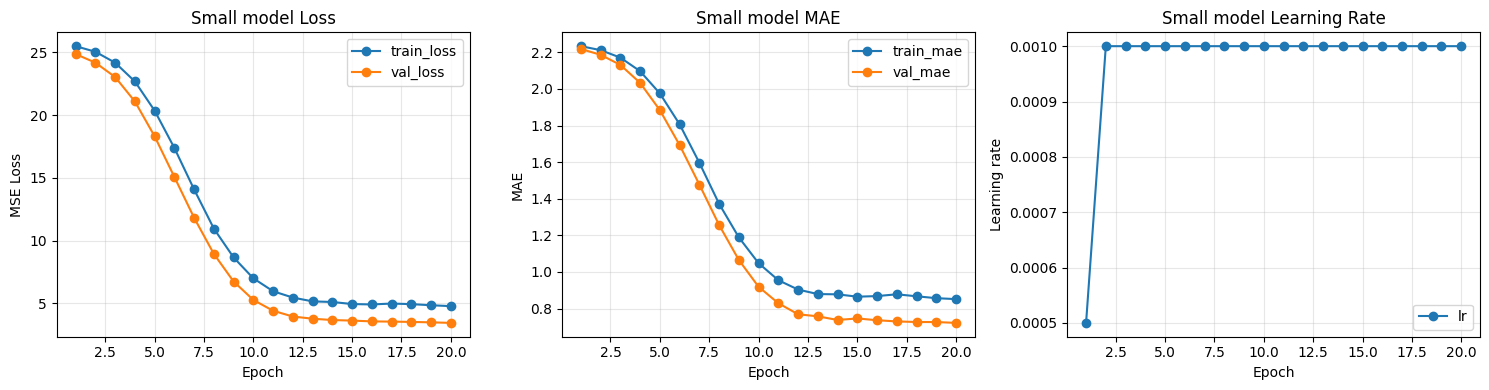

small | Test MSE: 3.0930 | Test MAE: 0.7216 | Test R2: 0.8700
Training model: medium
Epoch 1/20 | lr=0.000500 | train_loss=25.4904 | train_mae=2.2342 | val_loss=24.9414 | val_mae=2.2228 | val_r2=-0.0367
Epoch 2/20 | lr=0.001000 | train_loss=24.6024 | train_mae=2.1914 | val_loss=23.5493 | val_mae=2.1558 | val_r2=0.0211
Epoch 3/20 | lr=0.001000 | train_loss=22.4115 | train_mae=2.0812 | val_loss=19.6486 | val_mae=1.9539 | val_r2=0.1833
Epoch 4/20 | lr=0.001000 | train_loss=19.2748 | train_mae=1.9114 | val_loss=15.8095 | val_mae=1.7302 | val_r2=0.3428
Epoch 5/20 | lr=0.001000 | train_loss=15.6815 | train_mae=1.6959 | val_loss=12.1571 | val_mae=1.4916 | val_r2=0.4947
Epoch 6/20 | lr=0.001000 | train_loss=12.2240 | train_mae=1.4627 | val_loss=9.2369 | val_mae=1.2772 | val_r2=0.6160
Epoch 7/20 | lr=0.001000 | train_loss=9.1361 | train_mae=1.2340 | val_loss=6.6502 | val_mae=1.0628 | val_r2=0.7236
Epoch 8/20 | lr=0.001000 | train_loss=6.8621 | train_mae=1.0410 | val_loss=4.6503 | val_mae=0.8666

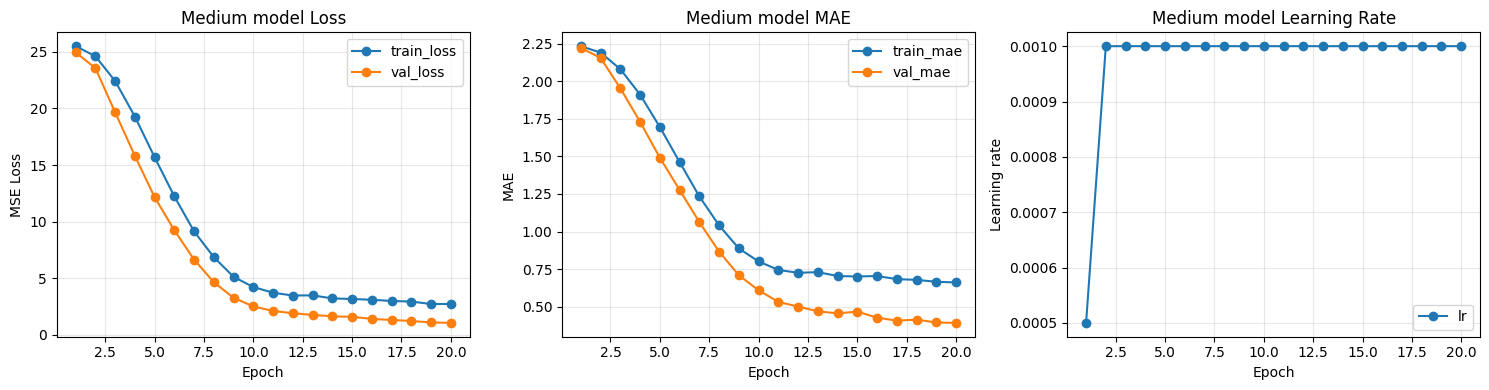

medium | Test MSE: 0.8212 | Test MAE: 0.3808 | Test R2: 0.9655
Training model: large
Epoch 1/20 | lr=0.000500 | train_loss=25.1410 | train_mae=2.2172 | val_loss=24.8092 | val_mae=2.2168 | val_r2=-0.0313
Epoch 2/20 | lr=0.001000 | train_loss=23.7658 | train_mae=2.1494 | val_loss=22.7163 | val_mae=2.1126 | val_r2=0.0557
Epoch 3/20 | lr=0.001000 | train_loss=21.3808 | train_mae=2.0268 | val_loss=18.1836 | val_mae=1.8694 | val_r2=0.2442
Epoch 4/20 | lr=0.001000 | train_loss=18.2999 | train_mae=1.8649 | val_loss=14.7978 | val_mae=1.6812 | val_r2=0.3849
Epoch 5/20 | lr=0.001000 | train_loss=14.8531 | train_mae=1.6624 | val_loss=11.7187 | val_mae=1.4897 | val_r2=0.5129
Epoch 6/20 | lr=0.001000 | train_loss=11.3475 | train_mae=1.4277 | val_loss=8.3645 | val_mae=1.2446 | val_r2=0.6523
Epoch 7/20 | lr=0.001000 | train_loss=8.4504 | train_mae=1.2122 | val_loss=5.6194 | val_mae=1.0013 | val_r2=0.7664
Epoch 8/20 | lr=0.001000 | train_loss=6.0697 | train_mae=1.0004 | val_loss=3.7567 | val_mae=0.7882

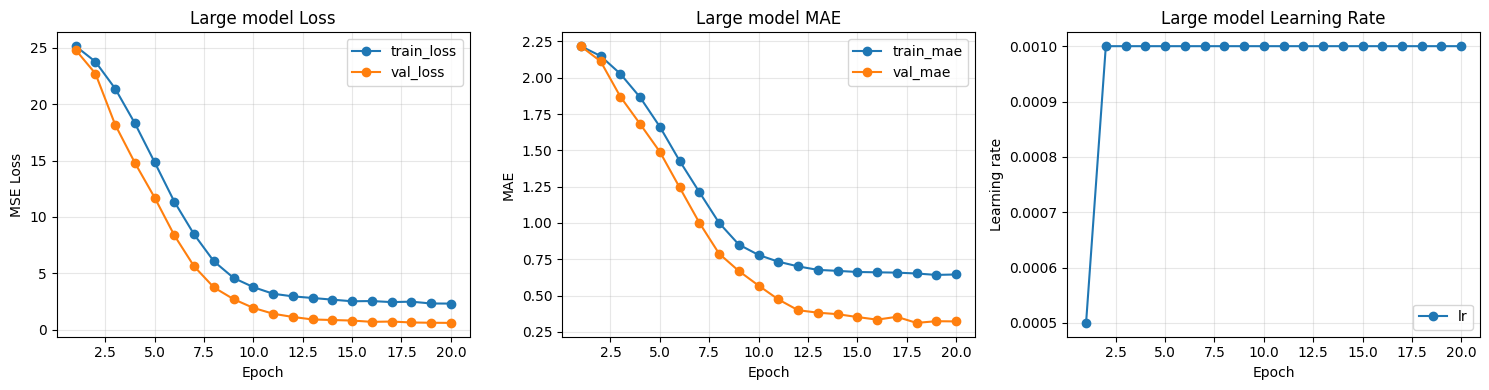

large | Test MSE: 0.5422 | Test MAE: 0.3197 | Test R2: 0.9772


In [83]:
results = {}

for model_size in ["small", "medium", "large"]:
    print("=" * 60)
    print("Training model:", model_size)

    model_reg = build_regression_model(
        model_size=model_size,
        n_in=X_train.shape[1],
        n_out=y_train.shape[1],
        activation="relu",
        dropout_p=0.2,
        bn_alpha=0.9
    )

    criterion_reg = MSECriterion()
    optimizer_reg = Adam(model_reg, lr=1e-3)
    scheduler_reg = ReduceLROnPlateau(optimizer_reg, factor=0.5, patience=2, min_lr=1e-5)

    history_reg = fit_regression(
        model=model_reg,
        criterion=criterion_reg,
        optimizer=optimizer_reg,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=20,
        batch_size=128,
        scheduler=scheduler_reg,
        warmup_epochs=2,
        early_stopping_patience=5,
        verbose=True
    )


    plot_regression_history(
        history_reg,
        title_prefix=f"{model_size.capitalize()} model"
    )

    test_loss, test_mae, test_r2 = evaluate_regression(
        model_reg, criterion_reg, X_test, y_test, batch_size=128
    )

    results[model_size] = {
        "history": history_reg,
        "test_mse": test_loss,
        "test_mae": test_mae,
        "test_r2": test_r2
    }

    print(f"{model_size} | Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f} | Test R2: {test_r2:.4f}")

Тест

In [85]:
test_loss, test_mae, test_r2 = evaluate_regression(
    model_reg, criterion_reg, X_test, y_test, batch_size=128
)

print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R2:  {test_r2:.4f}")

Test MSE: 0.5422
Test MAE: 0.3197
Test R2:  0.9772
